# OmicSieve TP53 Baseline (No Dimensionality Reduction)

This notebook is a fair baseline: all gene features are used directly for TP53 label prediction (no PHATE, no component selector MLP).

It reports:
1. Strict hold-out test performance (train+val -> test).
2. Exploratory 5-fold CV performance on merged data.

In [6]:
from pathlib import Path
import os
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score

# Reproducibility
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)

In [7]:
DATA_DIR = Path('/media/storage/Amir/Dataset/Deep Mut/')
MUT_INFO_PATH = DATA_DIR / 'mut_info.tsv'
RNASEQ_PATH = DATA_DIR / 'rnaseq_data.tsv'
META_PATH = DATA_DIR / 'meta_data.tsv'

meta_df = pd.read_csv(META_PATH, sep='\t')
header_df = pd.read_csv(RNASEQ_PATH, sep='\t', header=None, nrows=1, dtype=str)
gene_names = header_df.iloc[0, :].tolist()
rnaseq_df = pd.read_csv(RNASEQ_PATH, sep='\t', header=None, skiprows=1, dtype=str, engine='python', on_bad_lines='warn')

if rnaseq_df.shape[1] > len(gene_names):
    rnaseq_df = rnaseq_df.iloc[:, :len(gene_names)]
elif rnaseq_df.shape[1] < len(gene_names):
    for _ in range(len(gene_names) - rnaseq_df.shape[1]):
        rnaseq_df[len(rnaseq_df.columns)] = None

rnaseq_df.columns = gene_names
rnaseq_df = rnaseq_df.rename(columns={gene_names[0]: 'sample_id'})
print(f'RNA-seq shape: {rnaseq_df.shape}')

RNA-seq shape: (9626, 19311)


In [8]:
def _clean_meta(df: pd.DataFrame) -> pd.DataFrame:
    meta = df.copy()
    meta.columns = (
        meta.columns.astype(str)
        .str.strip()
        .str.strip('\"')
        .str.lower()
        .str.replace(' ', '_', regex=False)
    )
    if 'sample' in meta.columns:
        meta['patient_id'] = meta['sample'].astype(str).str.strip().str.replace('\"', '')
    meta = meta.dropna(subset=['patient_id']).drop_duplicates('patient_id')
    return meta

def _clean_rnaseq(df: pd.DataFrame) -> pd.DataFrame:
    gnames = df.columns.astype(str).str.strip().str.replace('\"', '')
    sample_ids = df.iloc[:, 0].astype(str).str.strip().str.replace('\"', '')
    expr_data = df.iloc[:, 1:].copy()
    expr_data.columns = gnames[:len(expr_data.columns)]
    expr_data = expr_data.apply(pd.to_numeric, errors='coerce')
    rna_clean = pd.concat([sample_ids.reset_index(drop=True), expr_data.reset_index(drop=True)], axis=1)
    rna_clean.columns = ['patient_id'] + list(expr_data.columns)
    rna_clean = rna_clean[rna_clean['patient_id'].str.len() > 0].dropna(subset=['patient_id'])
    rna_clean = rna_clean.set_index('patient_id')
    rna_final = rna_clean.groupby(level=0).mean()
    rna_final = rna_final.T
    rna_final['gene_id'] = rna_final.index
    rna_final = rna_final[['gene_id'] + [c for c in rna_final.columns if c != 'gene_id']]
    rna_final = rna_final.reset_index(drop=True)
    return rna_final

clean_meta_df = _clean_meta(meta_df)
clean_rnaseq_df = _clean_rnaseq(rnaseq_df)
rnaseq_patient_ids = set(clean_rnaseq_df.columns) - {'gene_id'}
matched_patient_ids = sorted(set(clean_meta_df['patient_id']) & rnaseq_patient_ids)
clean_meta_df = clean_meta_df[clean_meta_df['patient_id'].isin(matched_patient_ids)].reset_index(drop=True)
clean_rnaseq_df = clean_rnaseq_df[['gene_id'] + matched_patient_ids]

mut_df = pd.read_csv(MUT_INFO_PATH, sep='\t', dtype=str)
mut_df.columns = (
    mut_df.columns.astype(str)
    .str.strip()
    .str.strip('\"')
    .str.lower()
    .str.replace(' ', '_', regex=False)
)

index_ids = pd.Index(mut_df.index).astype(str)
index_tcga_fraction = index_ids.str.match(r'^TCGA-[A-Z0-9]+-[A-Z0-9]+-\d+').mean()
if index_tcga_fraction > 0.5:
    mut_df = mut_df.copy()
    mut_df['patient_id'] = index_ids.str.strip().str.replace('\"', '')
    id_col = 'patient_id'
else:
    id_candidates = ['patient_id', 'sample', 'x_patient', 'rnaseqid', 'sample_id', 'mutid']
    id_col = next((c for c in id_candidates if c in mut_df.columns), mut_df.columns[0])
    mut_df[id_col] = mut_df[id_col].astype(str).str.strip().str.replace('\"', '')

mut_df = mut_df.dropna(subset=[id_col]).drop_duplicates(id_col)
mutation_cols = [c for c in mut_df.columns if c != id_col]
tp53_col = next((c for c in mutation_cols if 'tp53' in c.lower()), None)

binary_mut_info = mut_df[[id_col, tp53_col]].copy()
binary_mut_info['mutation_label'] = binary_mut_info[tp53_col].apply(
    lambda x: 0 if str(x).strip().lower() == 'wild' else 1
)

mutation_by_patient = binary_mut_info.set_index(id_col)['mutation_label']
clean_meta_df['mutation_label'] = clean_meta_df['patient_id'].map(mutation_by_patient)
valid_idx = clean_meta_df['mutation_label'].notna()
labeled_meta_df = clean_meta_df[valid_idx].copy().reset_index(drop=True)
labeled_meta_df['mutation_label'] = labeled_meta_df['mutation_label'].astype(int)

valid_patient_ids = set(labeled_meta_df['patient_id'])
labeled_rnaseq_df = clean_rnaseq_df[['gene_id'] + sorted([p for p in clean_rnaseq_df.columns if p in valid_patient_ids])].reset_index(drop=True)

print(f'Found TP53 column: {tp53_col}')
print(f'Labeled metadata: {labeled_meta_df.shape}')
print(f'Labeled RNA-seq: {labeled_rnaseq_df.shape}')
print(labeled_meta_df['mutation_label'].value_counts().sort_index())

Found TP53 column: gene.tp53
Labeled metadata: (9626, 42)
Labeled RNA-seq: (19310, 9627)
mutation_label
0    6036
1    3590
Name: count, dtype: int64


In [9]:
def prepare_data(X, y, test_size=0.15, val_size=0.15, random_state=42, output_dir='deployment_mutation_baseline'):
    splitter1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_val_idx, test_idx = next(splitter1.split(X, y))

    X_train_val, y_train_val = X[train_val_idx], y[train_val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    val_size_adjusted = val_size / (1.0 - test_size)
    splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size_adjusted, random_state=random_state)
    train_idx, val_idx = next(splitter2.split(X_train_val, y_train_val))

    X_train, y_train = X_train_val[train_idx], y_train_val[train_idx]
    X_val, y_val = X_train_val[val_idx], y_train_val[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return {
        'X_train': X_train_scaled, 'y_train': y_train,
        'X_val': X_val_scaled, 'y_val': y_val,
        'X_test': X_test_scaled, 'y_test': y_test,
    }

X_raw = labeled_rnaseq_df.drop('gene_id', axis=1).T.values
y_binary = labeled_meta_df['mutation_label'].values.astype(int)
data = prepare_data(X_raw, y_binary)

print(data['X_train'].shape, data['X_val'].shape, data['X_test'].shape)

(6738, 19310) (1444, 19310) (1444, 19310)


Hold-out test report (train+val -> test):
  Accuracy:          0.8913
  Balanced Accuracy: 0.8923
  F1 (weighted):     0.8921
  Train time:        1478.30s


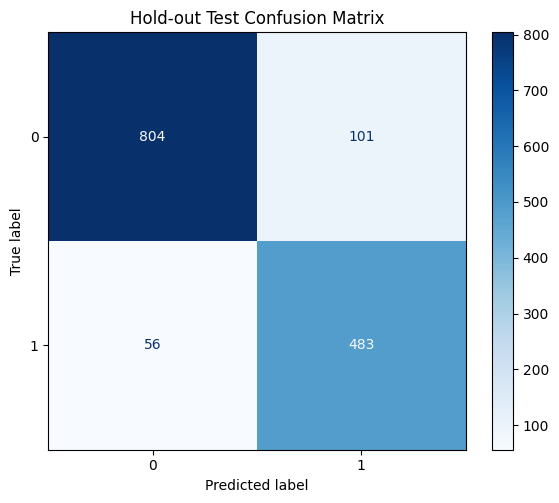


5-Fold CV report (merged data):
  Accuracy:          0.8855 +/- 0.0074
  Balanced Accuracy: 0.8845 +/- 0.0083
  F1 (weighted):     0.8862 +/- 0.0074


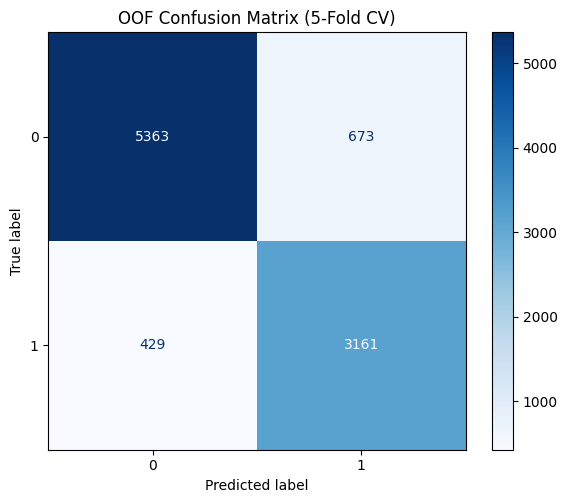

In [10]:
def run_tp53_baseline_with_holdout_and_cv(data, output_dir='deployment_mutation_baseline', n_splits=5, random_state=42):
    X_train, y_train = data['X_train'], data['y_train'].astype(int)
    X_val, y_val = data['X_val'], data['y_val'].astype(int)
    X_test, y_test = data['X_test'], data['y_test'].astype(int)

    # Hold-out report
    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])

    n_pos = int((y_trainval == 1).sum())
    n_neg = int((y_trainval == 0).sum())
    scale_pos_weight = float(n_neg) / float(max(n_pos, 1))
    n_samples = len(y_trainval)
    w_neg = n_samples / (2.0 * max(n_neg, 1))
    w_pos = n_samples / (2.0 * max(n_pos, 1))
    sample_weight = np.where(y_trainval == 1, w_pos, w_neg)

    xgb_holdout = xgb.XGBClassifier(
        n_estimators=350,
        max_depth=8,
        learning_rate=0.07,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        reg_lambda=5.0,
        gamma=0.0,
        scale_pos_weight=scale_pos_weight,
        max_delta_step=3,
        random_state=random_state,
        n_jobs=1,
        eval_metric='logloss',
    )

    t0 = time.time()
    xgb_holdout.fit(X_trainval, y_trainval, sample_weight=sample_weight)
    holdout_train_time = time.time() - t0

    y_pred_test = xgb_holdout.predict(X_test)
    holdout_accuracy = accuracy_score(y_test, y_pred_test)
    holdout_balanced_acc = balanced_accuracy_score(y_test, y_pred_test)
    holdout_f1 = f1_score(y_test, y_pred_test, average='weighted')
    holdout_cm = confusion_matrix(y_test, y_pred_test)

    print('Hold-out test report (train+val -> test):')
    print(f'  Accuracy:          {holdout_accuracy:.4f}')
    print(f'  Balanced Accuracy: {holdout_balanced_acc:.4f}')
    print(f'  F1 (weighted):     {holdout_f1:.4f}')
    print(f'  Train time:        {holdout_train_time:.2f}s')

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=holdout_cm, display_labels=sorted(np.unique(y_test)))
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title('Hold-out Test Confusion Matrix')
    plt.tight_layout()
    plt.show()
    plt.close()

    # CV on merged data
    X_all = np.vstack([X_train, X_val, X_test])
    y_all = np.concatenate([y_train, y_val, y_test])

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []
    y_oof_pred = np.zeros_like(y_all)

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), start=1):
        X_fold_train, X_fold_val = X_all[train_idx], X_all[val_idx]
        y_fold_train, y_fold_val = y_all[train_idx], y_all[val_idx]

        n_pos_f = int((y_fold_train == 1).sum())
        n_neg_f = int((y_fold_train == 0).sum())
        scale_pos_weight_f = float(n_neg_f) / float(max(n_pos_f, 1))
        n_samples_f = len(y_fold_train)
        w_neg_f = n_samples_f / (2.0 * max(n_neg_f, 1))
        w_pos_f = n_samples_f / (2.0 * max(n_pos_f, 1))
        sw_f = np.where(y_fold_train == 1, w_pos_f, w_neg_f)

        xgb_fold = xgb.XGBClassifier(
            n_estimators=350,
            max_depth=8,
            learning_rate=0.07,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1,
            reg_lambda=5.0,
            gamma=0.0,
            scale_pos_weight=scale_pos_weight_f,
            max_delta_step=3,
            random_state=random_state,
            n_jobs=1,
            eval_metric='logloss',
        )

        xgb_fold.fit(X_fold_train, y_fold_train, sample_weight=sw_f)
        y_fold_pred = xgb_fold.predict(X_fold_val)
        y_oof_pred[val_idx] = y_fold_pred

        fold_acc = accuracy_score(y_fold_val, y_fold_pred)
        fold_bal_acc = balanced_accuracy_score(y_fold_val, y_fold_pred)
        fold_f1 = f1_score(y_fold_val, y_fold_pred, average='weighted')
        fold_metrics.append({'fold': fold_idx, 'accuracy': fold_acc, 'balanced_accuracy': fold_bal_acc, 'f1_weighted': fold_f1})

    cv_accuracy = float(np.mean([m['accuracy'] for m in fold_metrics]))
    cv_balanced_accuracy = float(np.mean([m['balanced_accuracy'] for m in fold_metrics]))
    cv_f1_weighted = float(np.mean([m['f1_weighted'] for m in fold_metrics]))

    cv_accuracy_std = float(np.std([m['accuracy'] for m in fold_metrics]))
    cv_balanced_accuracy_std = float(np.std([m['balanced_accuracy'] for m in fold_metrics]))
    cv_f1_weighted_std = float(np.std([m['f1_weighted'] for m in fold_metrics]))

    cv_cm = confusion_matrix(y_all, y_oof_pred)
    print('\n5-Fold CV report (merged data):')
    print(f'  Accuracy:          {cv_accuracy:.4f} +/- {cv_accuracy_std:.4f}')
    print(f'  Balanced Accuracy: {cv_balanced_accuracy:.4f} +/- {cv_balanced_accuracy_std:.4f}')
    print(f'  F1 (weighted):     {cv_f1_weighted:.4f} +/- {cv_f1_weighted_std:.4f}')

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cv_cm, display_labels=sorted(np.unique(y_all)))
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title('OOF Confusion Matrix (5-Fold CV)')
    plt.tight_layout()
    plt.show()
    plt.close()

    return {
        'holdout_accuracy': holdout_accuracy,
        'holdout_balanced_accuracy': holdout_balanced_acc,
        'holdout_f1_weighted': holdout_f1,
        'holdout_confusion_matrix': holdout_cm,
        'holdout_confusion_matrix_path': None,
        'cv_accuracy': cv_accuracy,
        'cv_balanced_accuracy': cv_balanced_accuracy,
        'cv_f1_weighted': cv_f1_weighted,
        'cv_accuracy_std': cv_accuracy_std,
        'cv_balanced_accuracy_std': cv_balanced_accuracy_std,
        'cv_f1_weighted_std': cv_f1_weighted_std,
        'cv_confusion_matrix': cv_cm,
        'cv_confusion_matrix_path': None,
        'fold_metrics': fold_metrics,
        'reproducibility': {'seed': 42, 'xgboost_n_jobs': 1, 'cv_n_splits': n_splits}
    }

baseline_results = run_tp53_baseline_with_holdout_and_cv(data)